In [1]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from streamlit import title

Setting graphic style

In [2]:
sns.set_theme(style="darkgrid")

# Load local db

In [3]:
conn = sqlite3.connect('climate_data.db')
df = pd.read_sql_query("SELECT * FROM sensor_logs", conn)
conn.close()

# Convert time and set index

In [4]:
df['timestamp'] = pd.to_datetime(df['timestamp'], unit='ms')
df.set_index('timestamp', inplace=True)

Db info


In [5]:
df.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 1407 entries, 2026-04-25 19:17:49 to 2026-05-25 11:32:33
Data columns (total 12 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   id      1407 non-null   int64  
 1   year    1407 non-null   int64  
 2   month   1407 non-null   int64  
 3   day     1407 non-null   int64  
 4   hour    1407 non-null   int64  
 5   minute  1407 non-null   int64  
 6   second  1407 non-null   int64  
 7   temp    1407 non-null   float64
 8   hum     1407 non-null   float64
 9   press   1407 non-null   float64
 10  gas     1407 non-null   float64
 11  alt     1407 non-null   float64
dtypes: float64(5), int64(7)
memory usage: 142.9 KB


Display first 5 lines

In [6]:
display(df.head())

,id,year,month,day,hour,minute,second,temp,hum,press,gas,alt
timestamp,,,,,,,,,,,,
2026-04-25 19:17:49,1,2026,4,25,19,17,49,24.42,38.88,919.86,4.24,807.01
2026-04-25 19:47:51,2,2026,4,25,19,47,51,24.22,39.11,920.47,4.18,801.52
2026-04-25 20:17:52,3,2026,4,25,20,17,52,24.05,44.37,920.98,4.16,797.21
2026-04-25 20:47:53,4,2026,4,25,20,47,53,24.04,45.80,921.49,4.19,792.53
2026-04-25 21:17:54,5,2026,4,25,21,17,54,24.06,47.38,921.93,4.25,788.84


# Visualisation temperature for find anomalies

In [ ]:
plt.figure(figsize=(19,8))
plt.plot(df.index, df['temp'], color='coral', label='Temperature')
plt.title('Temperature History')
plt.xlabel('Date')
plt.ylabel('Temperature')
plt.legend()
plt.show()

- **Daily Seasonality**: The graph reveals a clear daily cycle, reflecting natural day-night temperature variations.

- **Anomalies / Outliers**: There are notable sudden drops and spikes in the data. These outliers likely correspond to external interventions, such as opening a window, or abrupt outdoor weather changes.

# Temperature map of correlations

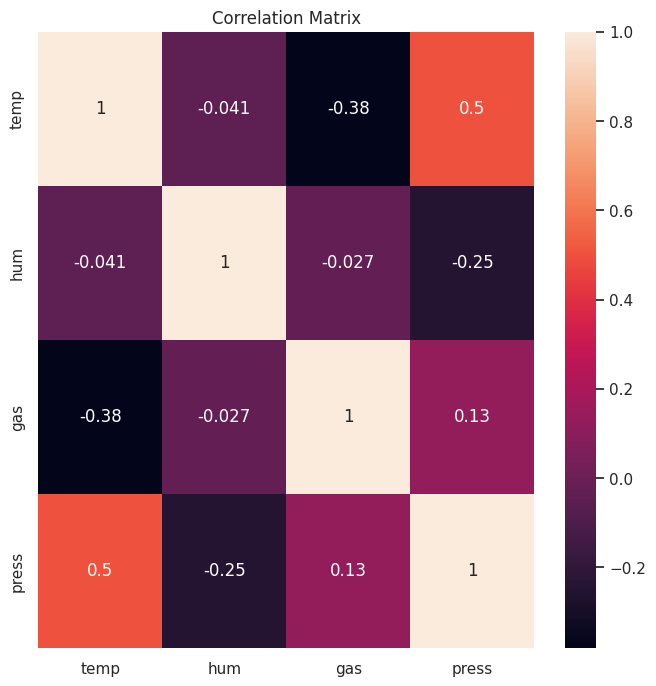

In [37]:
cols_to_corr = ['temp', 'hum', 'gas', 'press']
corr_matrix = df[cols_to_corr].corr()

plt.figure(figsize=(8,8))
sns.heatmap(corr_matrix, annot=True)
plt.title('Correlation Matrix')
plt.show()

- **Pressure (press = 0.50):** Displays a moderate positive correlation. It serves as a reliable proxy indicator for general weather conditions (e.g., high pressure usually brings clear, sunny weather, which warms the room).

- **Gas Resistance (gas = -0.38):** Shows a notable negative correlation. This metric acts as a proxy for human presence and indoor activity; as air quality drops (lower resistance), the temperature tends to rise due to body heat and electronics.

- **Humidity (hum = -0.041):** Exhibits almost zero correlation, indicating it is not a significant predictor for room temperature in this specific dataset.